# **Exploratory Data Analysis (EDA)**

---

## Project Overview

This project explores an e-commerce transaction dataset to uncover insights into sales performance, customer behaviour, product demand, and operational efficiency. Using Python, Pandas, and data visualisation techniques, the analysis transforms raw transaction records into actionable business intelligence that can support strategic decision-making.

The project demonstrates a complete analytics workflow, from data preparation and feature engineering to exploratory data analysis (EDA) and business-focused reporting.

### Business Problem / Objective

E-commerce businesses generate large volumes of transactional data, but identifying meaningful patterns requires systematic analysis.

The primary objectives of this project were to:

- Measure overall business performance using key sales metrics.
- Differentiate between Gross Revenue and Net Revenue to measure realised business performance.
- Quantify revenue lost through cancelled and returned orders
- Understand revenue trends over time.
- Identify products and locations driving business growth.
- Analyze customer acquisition and purchasing behavior.
- Evaluate operational efficiency through order fulfilment metrics.
- Assess the impact of discount usage on sales performance.

---


##### Load required Libraries

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Settings
sns.set_style('dark')

import warnings

#### Load Datset

In [2]:
file_name ='Cleaned_Dataset.xlsx'
df = pd.read_excel(file_name)

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


**Observations:**

- The dataset contains order transactions, customer details, products, payment methods, and fulfilment information. This provides a comprehensive view of the sales process and enables analysis of customer behaviour, product performance, operational efficiency, and revenue trends.

----

**Helper Columns for Trend Analysis:**

In [4]:
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%B')
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Year'] = df['Date'].dt.year

----

#### **Overall Key Performance Indicators**

In [5]:
# Sum Revenue (All Orders)
total_revenue = df['TotalPrice'].sum()

# Net Revenue (Delivered and Shipped Orders)
net_sales = df.loc[df['OrderStatus'].isin(['Delivered','Shipped']),'TotalPrice'].sum()

# Revenue lost from Cancelled and returned Orders
revenue_at_risk = total_revenue - net_sales 

print(f'Gross Revenue: ${total_revenue:,.2f}')
print(f'Net Revenue: ${net_sales:,.2f}')
print(f'Revenue Lost to Returns and Cancellation ${revenue_at_risk:,.2f}')

Gross Revenue: $1,264,761.96
Net Revenue: $488,759.90
Revenue Lost to Returns and Cancellation $776,002.06


**Observations:**

- The business generated over **`$1.26 million`** in sales revenue during the analysis period. However, actual realised revenue is lower considering cancelled and returned orders. This indicate the overall scale of commercial activity and serving as a key benchmark for future growth targets

----

In [6]:
# Customer Volume:
total_customers = df['CustomerID'].nunique()
print(f'Total Customers: {total_customers}')

Total Customers: 1189


**Observations:**

- The company served **`1,189`** unique customers, reflecting the size of its active customer base and providing a foundation for customer retention and acquisition strategies.

---

In [7]:
# Order Volume:
total_orders = df['OrderID'].nunique()
print(f'Total Orders: {total_orders}')

Total Orders: 1200


**Observations**

- Transactions volumes and overall demand for products were up to **`1,200`** orders.

---

In [8]:
# Order Value (all orders)
gross_aov = total_revenue / total_orders 

# Delivered and Cancelled Order
net_orders = df.loc[df['OrderStatus'].isin(['Delivered','Shipped']),'OrderID'].nunique()

# Net Average order value
net_aov = net_sales/net_orders

print(f'Gross Average Order Value: ${gross_aov:,.2f}')
print(f'Net Average Order Value: ${net_aov:,.2f}')

Gross Average Order Value: $1,053.97
Net Average Order Value: $1,048.84


**Observations**

- Customers spend an average of approximately **`$1,054`** per order **(gross AOV)** and **`$1,049`** per fulfilled order **(net AOV)**. The close alignment between these two metrics suggests that cancellations and returns have a relatively small impact on customer average spending, supporting confidence in pricing and revenue-generation strategies.

---

In [9]:
#Purchase rate
purchase_rate = df['Quantity'].sum() / df['ItemsInCart'].sum() 
print(f'Purchase Rate: {purchase_rate:.2%}')

Purchase Rate: 53.71%


**Observations:**

- Approximately **`54%`** of items added to shopping carts resulted in completed purchases. This highlights conversion efficiency and may indicate opportunities to reduce cart abandonment and improve the customer checkout experience.

---

#### **How Revenue Has Evolved Over Time**

- Shows overall performance and direction

**1. Gross vs Net Revenues By Months**

In [10]:
# Define Correct Month Order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Convert MonthName to Ordered Category
df['MonthName'] = pd.Categorical(
    df['MonthName'],
    categories=month_order,
    ordered=True
)

In [11]:
# Total Sales by Month(For all Orders)
gross_revenue = df.groupby('MonthName', observed=False)['TotalPrice'].sum().round(2).reset_index(name='GrossRevenue')

# Net revenue by Month (Delivered & Shipped Ordes)
net_revenue = df.loc[df['OrderStatus'].isin(['Delivered','Shipped'])].groupby('MonthName', observed=False)['TotalPrice'].sum().round(2).reset_index(name='NetRevenue')

# Revenue Metrics
monthly_revenue = pd.merge(gross_revenue,net_revenue, on='MonthName',how='left')

monthly_revenue

,MonthName,GrossRevenue,NetRevenue
0,January,124313.23,38669.24
1,February,112344.78,28641.15
2,March,123840.93,50642.89
3,April,109186.05,36184.14
4,May,135142.59,56799.38
5,June,170616.13,63201.56
6,July,85784.64,40633.84
7,August,86343.21,25678.74
8,September,69321.65,23282.39
9,October,89834.82,56935.12


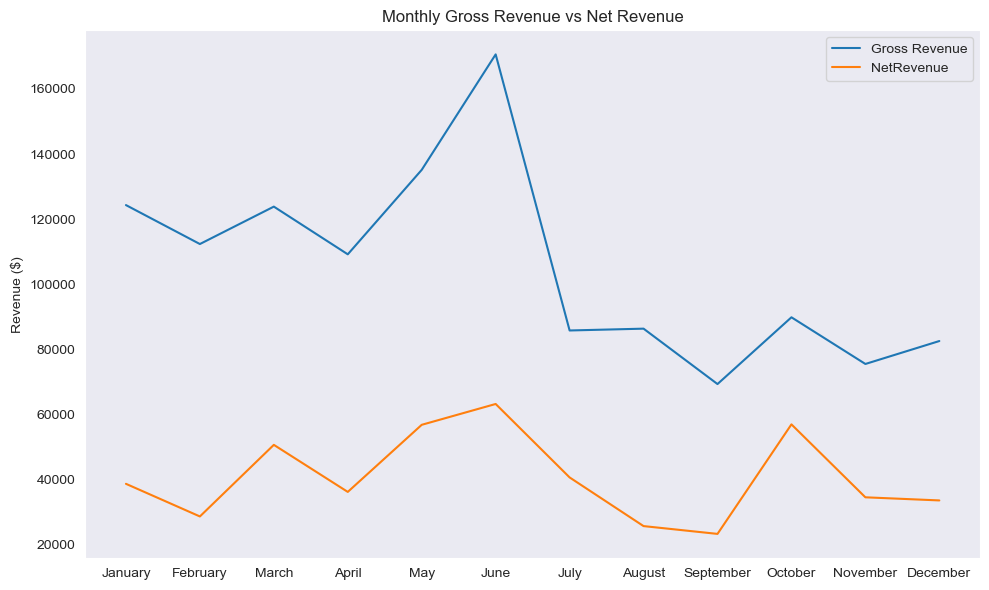

In [12]:
# Visualize Revenue Trends
plt.figure(figsize=(10,6))    
plt.plot(monthly_revenue['MonthName'], monthly_revenue['GrossRevenue'],label='Gross Revenue')
plt.plot(monthly_revenue['MonthName'], monthly_revenue['NetRevenue'],label='NetRevenue')
plt.title('Monthly Gross Revenue vs Net Revenue')
plt.ylabel('Revenue ($)')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

- The above chart compares total sales generated **(gross revenue)** with revenue from successfully fulfilled orders **(net revenue)** across each month. The gap between the two lines highlights the financial impact of cancellation, pending and returns, helping stakeholders identify periods where operational inefficiency or customer dissatisfaction may have reduced revenue.
  
- A small gap suggests fulfilment performance, while a larger gap may indicate an opportunity to improve customer experience and order completion rate.

- The monthly revenue trend reveals periods of strong and weak sales performance throughout the year. Identifying seasonal demand patterns help management improve inventory planning, marketing campaigns timing, staff decisions and revenue forecasting

----

**2. Weekly Order Performance**

In [13]:
# Define Weekday Name Order
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Convert Weekday Name In Categorical Order
df['DayOfWeek'] = pd.Categorical(
    df['DayOfWeek'],
    categories= days_order,
    ordered=True
)

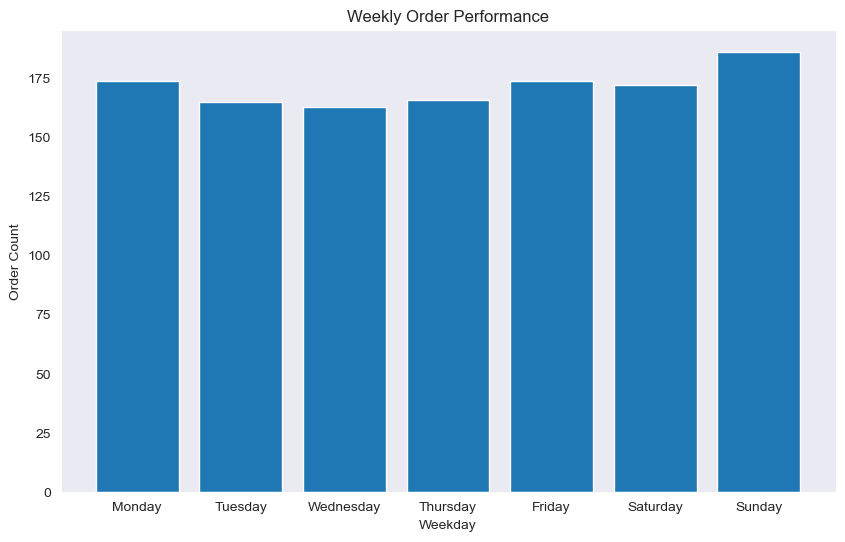

In [14]:
# Group Orders by weekday
weekly_orders = df.groupby('DayOfWeek', observed=False)['OrderID'].nunique().reset_index().sort_values('DayOfWeek')


# Visualize Orders by weekday
plt.figure(figsize=(10,6))
plt.bar(weekly_orders['DayOfWeek'],weekly_orders['OrderID'])

plt.title('Weekly Order Performance')
plt.xlabel('Weekday')
plt.ylabel('Order Count')
plt.show()

**Interpretation:**

- Order activity by day of the week highlights peak purchasing periods and customer buying behaviour. These insights can guide promotional scheduling, workforce allocation and operation planning to maximise sales opportunity during high-demand days.

----

#### **Drivers of Performance**

- Key contributors

**1. Gross vs Net Revenue by Location**

In [15]:
# Gross sales by location
location_sales = df.groupby('ShippingAddress')['TotalPrice'].sum().reset_index(name='LocationGrossRevenue')

# Net sales (Delivered & Shipped Ordes)
location_net_revenue = df.loc[df['OrderStatus'].isin(['Delivered','Shipped'])].groupby('ShippingAddress', observed=False)['TotalPrice'].sum().round(2).reset_index(name='LocationNetRevenue')

#Combine Gross and Net Revenues
location_revenue = pd.merge(location_sales,location_net_revenue,on='ShippingAddress',how='left')

#Revenue Lost from Pendings, Returns and Cancellation
location_revenue['RevenueAtRisk'] = (location_revenue['LocationGrossRevenue']- 
                                     location_revenue['LocationNetRevenue'])

# Sort Values by Revenue lost
location_revenue = location_revenue.sort_values('RevenueAtRisk',ascending=False).reset_index(drop=True)

# Revenue Realization rate
location_revenue['RevenueRealizationRate'] = (location_revenue['LocationNetRevenue']/
                                              location_revenue['LocationGrossRevenue']).round(2) * 100

location_revenue.head(10)

,ShippingAddress,LocationGrossRevenue,LocationNetRevenue,RevenueAtRisk,RevenueRealizationRate
0,533 Main St,7753.73,2091.20,5662.53,27.0
1,740 Main St,6761.84,1213.86,5547.98,18.0
2,447 Main St,5816.18,660.66,5155.52,11.0
3,922 Main St,6367.75,1278.36,5089.39,20.0
4,129 Main St,6065.66,1105.28,4960.38,18.0
5,788 Main St,5163.64,474.25,4689.39,9.0
6,319 Main St,5270.07,984.20,4285.87,19.0
7,160 Main St,6536.79,2329.04,4207.75,36.0
8,522 Main St,4409.76,241.90,4167.86,5.0
9,967 Main St,4339.97,330.98,4008.99,8.0


**Interpretation:**

- Comparing gross and net revenue by location helps identify high-performing locations while accounting for cancellations, returns and pending orders. The revenue metric highlights locations where a larger share of sales fails to convert into realised revenue, enabling targeted improvements in customer service, fulfilment processes and regional sales strategies.

---

**2. Product Driving Most Order and Revenue**


In [16]:
# Gross Product Performance
product_gross = df.groupby('Product').agg(GrossOrderCount=('OrderID','nunique'),
                                          GrossRevenue=('TotalPrice','sum')).reset_index()

# Net Product Performance (Shipped and Delivered)
product_net = df.loc[df['OrderStatus'].isin(['Delivered','Shipped'])].groupby('Product').agg(NetOrderCount=('OrderID','nunique'),
                                                                                             NetRevenue=('TotalPrice','sum')).reset_index()

# Combine Net and Gross performance
product_perfomance = pd.merge(product_gross,
                              product_net,
                              on='Product',
                              how='left')

# Revenue at risk
product_perfomance['RevenueAtRisk'] = (product_perfomance['GrossRevenue']-
                                       product_perfomance['NetRevenue'])

# Sort values by Net Revenue
product_perfomance = product_perfomance.sort_values('NetRevenue', ascending=False).reset_index(drop=True)

product_perfomance

,Product,GrossOrderCount,GrossRevenue,NetOrderCount,NetRevenue,RevenueAtRisk
0,Printer,181,195612.61,71,82452.14,113160.47
1,Laptop,173,192126.56,69,80951.66,111174.90
2,Chair,178,195620.11,64,71816.27,123803.84
3,Monitor,163,175651.41,63,66924.44,108726.97
4,Tablet,179,186568.95,68,66622.67,119946.28
5,Phone,156,151722.39,66,62342.05,89380.34
6,Desk,170,167459.93,65,57650.67,109809.26


**Interpretation:**

- Product performance should be assessed using both gross and net revenue. Gross revenue shows overall customer demand, while net revenue reflects the actual realisation from fulfilled orders. Revenue at risk highlights the impact of cancellation, return and pending orders.

- `Chairs`, `Printers`, and `Laptops` are the strongest contributors to revenue, making them strategically important products for inventory investments, promotional campaigns and supplier relationship management. Products with lower sales may require pricing reviews and targeted marketing efforts

----

#### **Customer Behavior**

- To understand how customers interact, revealing behaviour patterns

**1. Where Are Our Customers Coming From?**

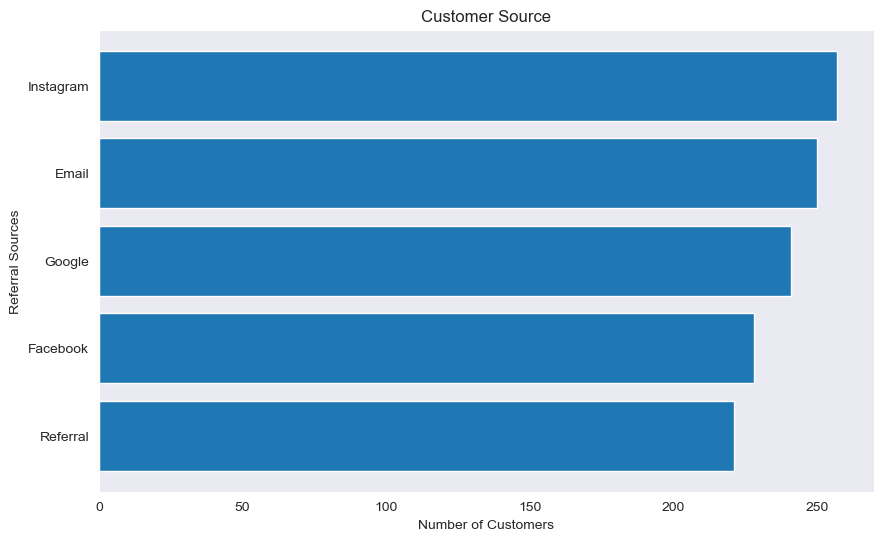

In [17]:
# Group Customer Count by Referral Source
traffic = df.groupby('ReferralSource')['CustomerID'].nunique().sort_values(ascending=True).reset_index()

# Visualize as a bar chart
plt.figure(figsize=(10,6))
plt.barh(traffic['ReferralSource'],traffic['CustomerID'])

plt.title('Customer Source')
plt.xlabel('Number of Customers')
plt.ylabel('Referral Sources')
plt.show()

**Interpretation:**

- Referral analysis identifies which marketing channels contribute the most customers. Understanding acquisition performance helps optimise marketing budgets and focus resources on the highest-performing channels.

---

**2. How Do Customers Prefer to Pay?** 


In [18]:
# Categorise number of customers by payment method
payment_method = df.groupby('PaymentMethod').agg({'CustomerID':'count'}).sort_values(by='CustomerID',ascending=False).reset_index()
payment_method.rename(columns={'CustomerID':'NumberOfCustomers'},inplace=True)
payment_method                                    

,PaymentMethod,NumberOfCustomers
0,Online,258
1,Cash,246
2,Credit Card,234
3,Debit Card,232
4,Gift Card,230


**Interpretation:**

- Customer adoption is relatively balanced across payment methods, with online payments leading slightly. This suggest that maintaining payments options is important for customers' convenience and sales conversions

---

**3. Customer spending distribution**

- That is the spending variability:

In [19]:
# Total Spending per Customer
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum().round(2).reset_index()
customer_spending.rename(columns={'TotalPrice':'TotalSpent'}, inplace=True)

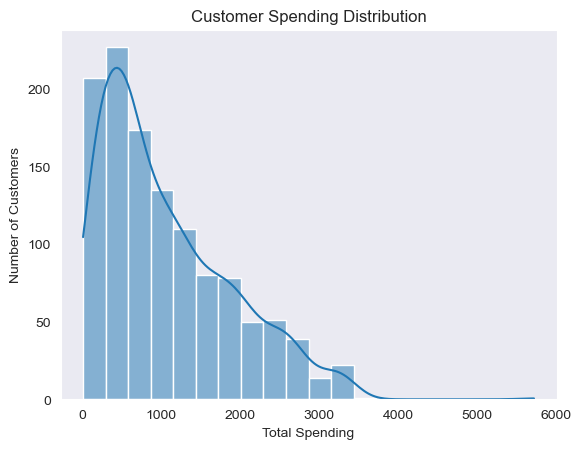

In [20]:
# Visualize Customer Spendings
sns.histplot(customer_spending['TotalSpent'],bins=20,kde=True)
plt.title('Customer Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.show()

**Interpretation:**

- The spending distribution highlights differences in customer purchasing value. Identifying high-spending customer segments enables the business to develop loyalty programs, personalised offers, and retention strategies that maximize customer lifetime value

----

#### **Operational Performance**

- Monitor efficiency and fulfillment
- And, assess pricing and promotion impact

**1. Orders Status across the Pipeline?**

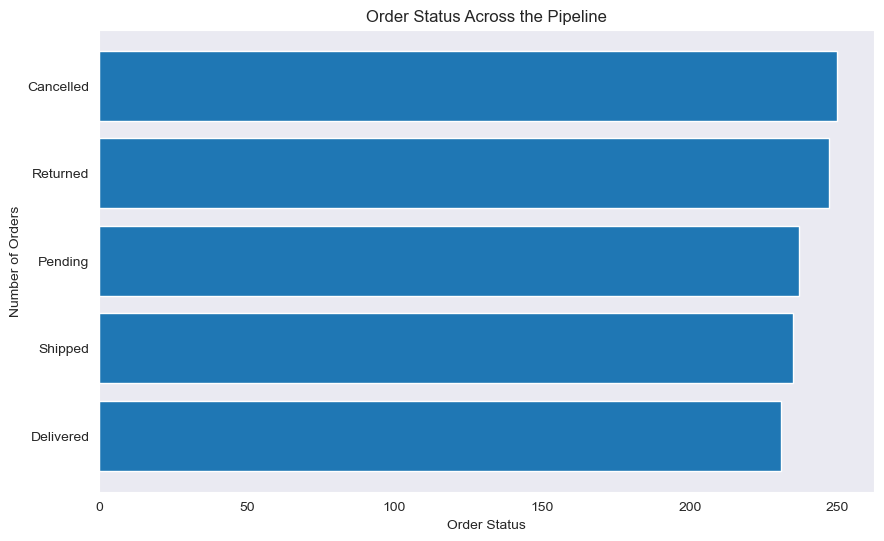

In [21]:
# Categorise Order status
orders_status = df.groupby('OrderStatus')['OrderID'].nunique().sort_values(ascending=True).reset_index()

# Visualize order status
plt.figure(figsize=(10,6))
plt.barh(orders_status['OrderStatus'],orders_status['OrderID'])

plt.title('Order Status Across the Pipeline')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.show()

**Interpretation:**

- Tracking order statuses provides visibility into fulfilment efficiency and customer service performance. A high proportion of delivered orders indicate operational effectiveness, while elevated cancellation or return signals process, product quality or customer satisfaction issues requiring attention

---
**2. How Often Are Discounts Used in Orders?**

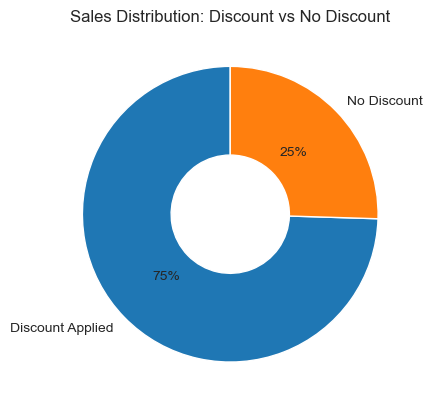

In [22]:
# Identify Discount Usage
df['UsedCoupon'] = np.where(df['CouponCode'] == 'No Coupon',
                            'No Discount', 
                            'Discount Applied')

# Average Order value with Coupon
discount_anlysis = df.groupby('UsedCoupon')['TotalPrice'].sum()

# Visualize discount impact
plt.pie(
    discount_anlysis,
    labels = discount_anlysis.index,
    autopct='%1.0f%%',
    startangle = 90,
    wedgeprops={'width':0.6}
)
plt.title('Sales Distribution: Discount vs No Discount')
plt.show()

**Interpretation:**
- The discount analysis measures the contribution of the promotional offers to overall sales. Understanding the proportion of revenue generated through discounts help evaluate promotion effectiveness, profitability, and the business dependency on price incentives to drive purchase

----

#### **Summary**

The analysis reveals a business that generated over **`$1.26`** million in gross revenue from **`1,200`** orders across **`1,189`** customers, with a gross average order value of approximately **`$1,054`** and a net average order value of approximately **`$1,049`** after accounting for fulfilled orders. 

Comparing gross revenue and net revenue provides a more accurate view of business performance by highlighting the financial impact of cancelled, returned and pending orders. revenue performance is influenced by seasonal sales pattern, location demand variation and a small group od high-performing

Customer acquisition channels, payment preferences, and spending behaviour provide opportunities for targeted marketing and customer retention initiatives.

Operational metrics such as purchase conversion, order fulfillment status, and discount utilization offer actionable insights for improving efficiency and customer experience, and long-term profitability